# LIBRARY

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict


In [123]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, classification_report,
                             roc_curve, auc)
import numpy as np
import matplotlib.pyplot as plt

In [124]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np

In [125]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE

In [126]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [127]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [128]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.calibration import CalibratedClassifierCV  # ← needed for predict_proba
import numpy as np

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report

In [130]:
def print_dist(y, label, binary=False):
    unique, counts = np.unique(y, return_counts=True)
    proportions    = counts / counts.sum()
    prefix         = 'binary=' if binary else 'sii='
    df = pd.DataFrame({
        'Class':      [f'{prefix}{u}' for u in unique],
        'Count':      counts,
        'Proportion': proportions.round(4),
        'Percentage': (proportions * 100).round(2)
    })
    print(f"\n{'='*60}")
    print(f"  SET: {label}")
    print(df.to_string(index=False))

# READ DATAFRAME

In [131]:
file_path = "../1.DATASET/CMI_FINAL_OD_SS.csv"
df=pd.read_csv(file_path)

In [132]:
df

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
0,0,-1.467073,-0.822843,-0.561893,-1.343231,-1.008221,-0.250870,-0.956432,-0.428812,-0.942872,-0.939966,-0.992591,-0.818300,-0.947148,-0.726336,-1.265162,-0.874740,-0.859871,2.0
1,1,-0.338700,-0.822843,-1.221382,-1.083906,-1.128018,0.630346,-0.657546,-0.367405,1.285851,-0.939966,-1.033298,-0.804797,-0.932563,-1.053662,-1.265162,-1.226847,-1.273565,0.0
2,2,-0.056607,1.215298,-0.614950,0.018225,-0.389269,-0.232187,1.018179,-1.466511,0.790579,0.280796,-0.662859,-0.199213,-0.347769,-0.314411,0.512640,-0.355318,-0.148634,0.0
3,3,-0.338700,-0.822843,-0.233502,-0.046607,-0.239523,-0.577200,0.665395,-0.367405,-0.695236,0.280796,-0.456268,0.057750,-0.249394,-0.126332,0.512640,-0.283279,0.116846,1.0
4,4,2.200139,1.215298,-0.315811,-0.224763,-0.375806,0.577087,-0.304761,1.210082,-0.198377,0.280796,3.297345,1.538145,-0.330005,-0.314411,0.512640,0.009328,-0.148634,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8377,8455,-0.902887,1.215298,-0.735189,-1.334155,-1.060626,-0.281071,-0.789840,-0.392148,-0.695236,-2.160727,-1.012064,-0.820639,-0.817405,-1.103413,-1.265162,-1.004029,-0.941197,0.0
8378,8456,-0.056607,1.215298,-0.463799,-0.029751,-0.341052,-0.490946,-0.613448,-1.251639,-1.685780,0.280796,0.067523,-0.439950,-0.015430,-0.823890,-1.265162,-0.581341,-0.582047,1.0
8379,8457,-0.056607,1.215298,5.021847,-0.881633,1.293649,-0.249437,0.533101,-0.627980,0.542943,1.501557,-0.388344,-0.705917,1.239140,0.886735,0.512640,0.152734,-0.682526,0.0
8380,8458,1.353859,1.215298,0.742981,0.963464,0.974332,0.395292,-0.481153,1.201246,1.038215,-0.939966,0.058376,-0.447250,1.092211,0.366529,0.512640,1.420549,0.963516,2.0


In [133]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8382, 17)
y shape : (8382,)
Classes : [0. 1. 2. 3.]
Class counts : {0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85}


# Data Preparation

In [134]:
X.shape

(8382, 17)

In [135]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5794, 1567,  936,   85], dtype=int64))

In [136]:
Counter(y)

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

In [137]:
ctr = Counter(y)
ctr

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

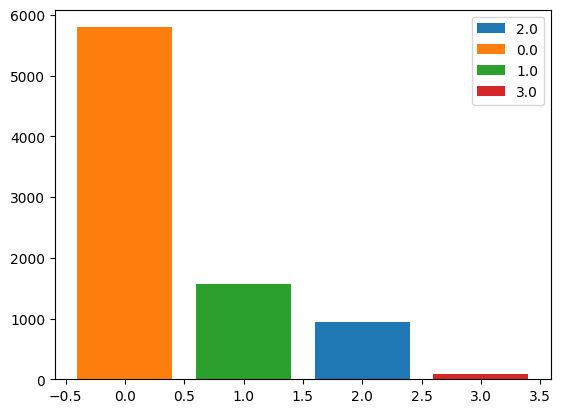

In [138]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange','tab:green','tab:red'])
plt.legend()
plt.show()

## Data Partitioning

In [139]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [140]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [141]:
X_train.shape

(5867, 17)

In [142]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0., 1., 2., 3.]), array([4056, 1097,  655,   59], dtype=int64)),
 (array([0., 1., 2., 3.]), array([1738,  470,  281,   26], dtype=int64)))

In [143]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.6913243565706494

In [144]:

print(f"Train samples : {len(y_train)}")
print(f"Test samples  : {len(y_test)}")

Train samples : 5867
Test samples  : 2515


# CASCADE

## model

In [ ]:
param_list = [
    # l2 + hinge — requires dual=True
    {
        'C':            [0.001,0.01, 0.1, 1, 10, 100, 1000],
        'penalty':      ['l2'],
        'loss':         ['hinge'],
        'dual':         [True],
        'max_iter':     [500, 1000, 2000, 5000],
        'class_weight': ['balanced', None],
    },
    # l2 + squared_hinge — dual True or False
    {
        'C':            [0.001,0.01, 0.1, 1, 10, 100, 1000],
        'penalty':      ['l2'],
        'loss':         ['squared_hinge'],
        'dual':         [True, False],
        'max_iter':     [500, 1000, 2000, 5000],
        'class_weight': ['balanced', None],
    },
    # l1 + squared_hinge — requires dual=False
    {
        'C':            [0.001,0.01, 0.1, 1, 10, 100, 1000],
        'penalty':      ['l1'],
        'loss':         ['squared_hinge'],
        'dual':         [False],
        'max_iter':     [500, 1000, 2000, 5000],
        'class_weight': ['balanced', None],
    },
]

In [146]:
def train_one_step_svm(X_train, y_binary, X_test, y_test_binary, step_name,
                       n_iter=50, n_splits=5, random_state=0):

    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

    # ── Random search on LinearSVC ────────────────────────────────────────────
    # NOTE: search on LinearSVC directly (faster)
    # calibration is applied AFTER finding best params
    random_search = RandomizedSearchCV(
        LinearSVC(random_state=random_state),
        param_distributions=param_list,
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring='f1_weighted',
        n_jobs=-1,
        refit=True,
        n_iter=n_iter,
        random_state=random_state,
        error_score='raise',
    )
    random_search.fit(X_train, y_binary)

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")

    # ── Wrap best model with calibration to enable predict_proba ─────────────
    # LinearSVC has no predict_proba natively
    # CalibratedClassifierCV adds it via Platt scaling
    calibrated_model = CalibratedClassifierCV(
        LinearSVC(**random_search.best_params_,
                  random_state=random_state),
        cv=5
    )
    calibrated_model.fit(X_train, y_binary)

    # ── Predictions ───────────────────────────────────────────────────────────
    y_pred_binary = calibrated_model.predict(X_test)
    y_proba       = calibrated_model.predict_proba(X_test)[:, 1]  # P(positive)

    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    print(f"  Test F1     : {test_f1:.4f}")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm   = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f'not {step_name}', step_name]
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.tight_layout()
    plt.show()

    # ── ROC curve ─────────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
    roc_auc     = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='#7F77DD', linewidth=2,
             label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {step_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # ── Reports ───────────────────────────────────────────────────────────────
    print(classification_report(y_test_binary, y_pred_binary,
                                target_names=[f'not {step_name}', step_name]))

    print(f"\n  Confusion Matrix breakdown:")
    print(f"    TN (correct negatives) : {cm[0,0]}")
    print(f"    FP (false positives)   : {cm[0,1]}")
    print(f"    FN (false negatives)   : {cm[1,0]}")
    print(f"    TP (correct positives) : {cm[1,1]}")
    print(f"    AUC                    : {roc_auc:.4f}")

    return calibrated_model     # ← return calibrated model, not raw LinearSVC

## split 

In [147]:
# 
step_results = {}   
y_pred_final = np.full(len(X_test), -1)
original_idx = np.arange(len(X_test))

# Working copies that shrink at each cascade step
X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2. 3.]
Train samples  : 5867
Test samples   : 2515


In [148]:
print_dist(y_tr, 'TRAIN')
print_dist(y_te, 'TEST')


  SET: TRAIN
  Class  Count  Proportion  Percentage
sii=0.0   4056      0.6913       69.13
sii=1.0   1097      0.1870       18.70
sii=2.0    655      0.1116       11.16
sii=3.0     59      0.0101        1.01

  SET: TEST
  Class  Count  Proportion  Percentage
sii=0.0   1738      0.6911       69.11
sii=1.0    470      0.1869       18.69
sii=2.0    281      0.1117       11.17
sii=3.0     26      0.0103        1.03


### class 0

In [149]:
# ── STEP 1: sii=0 vs [1, 2, 3] ───────────────────────────────────────────
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [150]:
print_dist(y_binary_tr, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   1811      0.3087       30.87
binary=1   4056      0.6913       69.13

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    777      0.3089       30.89
binary=1   1738      0.6911       69.11


In [151]:
# from imblearn.over_sampling import SMOTE
# over_dic={0:3500}
# #under_dic={0:3000}
# over = SMOTE(random_state=42, sampling_strategy=over_dic)
# #under = TomekLinks(sampling_strategy='majority')
# X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
# print('Resampled dataset shape %s' % Counter(y_res))


  STEP: sii=0
  Training samples : 5867
  Positive class   : 4056 samples
  Negative class   : 1811 samples



  Best params : {'penalty': 'l1', 'max_iter': 1000, 'loss': 'squared_hinge', 'dual': False, 'class_weight': 'balanced', 'C': 0.001}
  Best CV F1  : 0.6501
  Test F1     : 0.6247


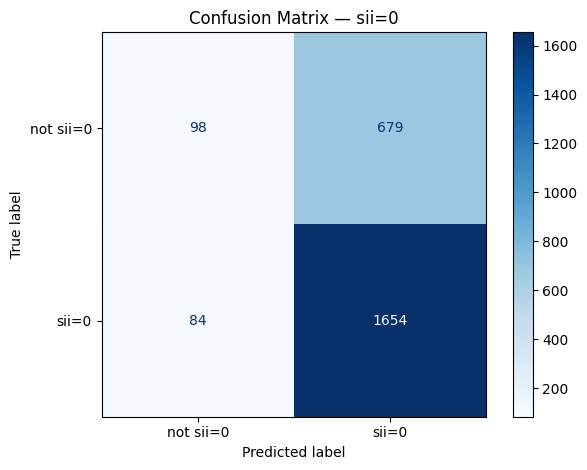

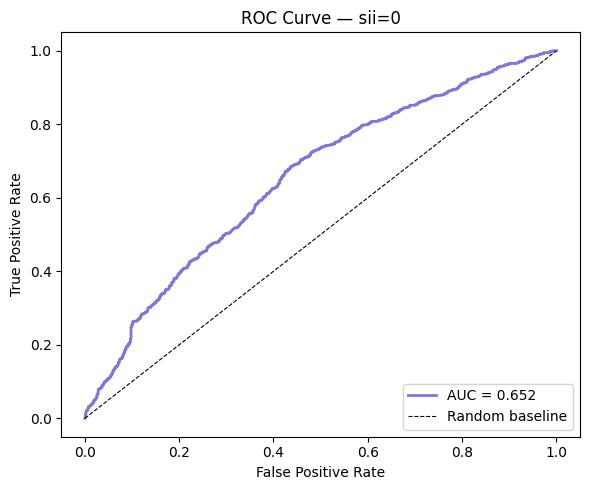

              precision    recall  f1-score   support

   not sii=0       0.54      0.13      0.20       777
       sii=0       0.71      0.95      0.81      1738

    accuracy                           0.70      2515
   macro avg       0.62      0.54      0.51      2515
weighted avg       0.66      0.70      0.62      2515


  Confusion Matrix breakdown:
    TN (correct negatives) : 98
    FP (false positives)   : 679
    FN (false negatives)   : 84
    TP (correct positives) : 1654
    AUC                    : 0.6522


In [152]:
models[0] = train_one_step_svm(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=0')

In [153]:
# samples predicted as sii=0 → assign 0 to their original position
y_pred_te   = models[0].predict(X_te)

#----------------------------------
step_results[0] = {
    'step_name':    'sii=0 vs [1,2,3]',
    'y_true_bin':   y_binary_te.copy(),      # verdadero binario
    'y_pred_bin':   y_pred_te.copy(),        # predicho binario
    'y_true_orig':  y_te.copy(),             # verdadero multiclass en este paso
    'original_idx': original_idx.copy(),     # índices originales
}

y_pred_final[original_idx[y_pred_te == 1]] = 0

print(f"\n  Assigned as sii=0 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=0 : 2333 samples


### class 1 

In [154]:
# TRAIN → remove all true sii=0 
mask_tr      = y_tr != 0
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink index tracker too

In [155]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 1')
print_dist(y_te, 'TEST  after step 1')

  Remaining train : 1811
  Remaining test  : 861

  SET: TRAIN after step 1
  Class  Count  Proportion  Percentage
sii=1.0   1097      0.6057       60.57
sii=2.0    655      0.3617       36.17
sii=3.0     59      0.0326        3.26

  SET: TEST  after step 1
  Class  Count  Proportion  Percentage
sii=0.0     84      0.0976        9.76
sii=1.0    470      0.5459       54.59
sii=2.0    281      0.3264       32.64
sii=3.0     26      0.0302        3.02


In [156]:
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)

In [157]:
print_dist(y_binary_tr, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    714      0.3943       39.43
binary=1   1097      0.6057       60.57

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    391      0.4541       45.41
binary=1    470      0.5459       54.59



  STEP: sii=1
  Training samples : 1811
  Positive class   : 1097 samples
  Negative class   : 714 samples

  Best params : {'penalty': 'l2', 'max_iter': 2000, 'loss': 'hinge', 'dual': True, 'class_weight': 'balanced', 'C': 0.1}
  Best CV F1  : 0.5904
  Test F1     : 0.5919


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


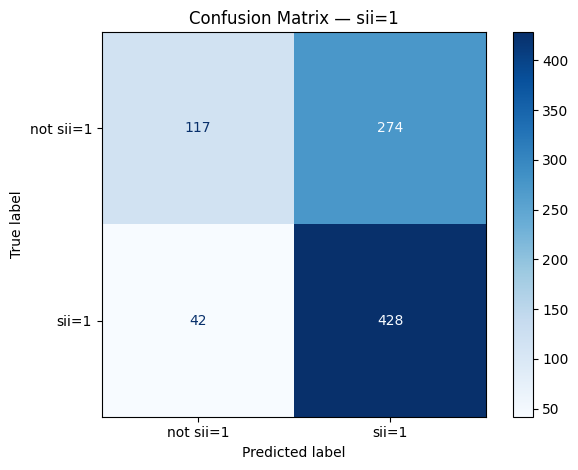

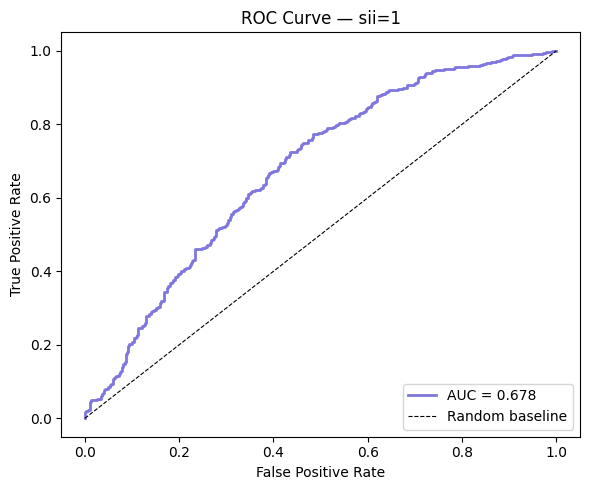

              precision    recall  f1-score   support

   not sii=1       0.74      0.30      0.43       391
       sii=1       0.61      0.91      0.73       470

    accuracy                           0.63       861
   macro avg       0.67      0.60      0.58       861
weighted avg       0.67      0.63      0.59       861


  Confusion Matrix breakdown:
    TN (correct negatives) : 117
    FP (false positives)   : 274
    FN (false negatives)   : 42
    TP (correct positives) : 428
    AUC                    : 0.6781


In [158]:
models[1] = train_one_step_svm(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=1')

In [159]:
y_pred_te   = models[1].predict(X_te)

step_results[1] = {
    'step_name':    'sii=1 vs [2,3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 1

print(f"\n  Assigned as sii=1 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=1 : 702 samples


### class 2

In [160]:
# TRAIN → remove all true sii=1
mask_tr      = y_tr != 1
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES 
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

In [161]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 2')
print_dist(y_te, 'TEST  after step 2')

  Remaining train : 714
  Remaining test  : 433

  SET: TRAIN after step 2
  Class  Count  Proportion  Percentage
sii=2.0    655      0.9174       91.74
sii=3.0     59      0.0826        8.26

  SET: TEST  after step 2
  Class  Count  Proportion  Percentage
sii=0.0     84       0.194        19.4
sii=1.0     42       0.097         9.7
sii=2.0    281       0.649        64.9
sii=3.0     26       0.060         6.0


In [162]:
y_binary_tr = (y_tr == 2).astype(int)
y_binary_te = (y_te == 2).astype(int)

In [163]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0     59      0.0826        8.26
binary=1    655      0.9174       91.74

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    152       0.351        35.1
binary=1    281       0.649        64.9


In [164]:
# from imblearn.over_sampling import SMOTE
# over_dic={0:500}
# #under_dic={0:3000}
# over = SMOTE(random_state=42, sampling_strategy=over_dic)
# #under = TomekLinks(sampling_strategy='majority')
# X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
# print('Resampled dataset shape %s' % Counter(y_res))


In [165]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0     59      0.0826        8.26
binary=1    655      0.9174       91.74

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    152       0.351        35.1
binary=1    281       0.649        64.9



  STEP: sii=2
  Training samples : 714
  Positive class   : 655 samples
  Negative class   : 59 samples


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-pack


  Best params : {'penalty': 'l2', 'max_iter': 1000, 'loss': 'squared_hinge', 'dual': True, 'class_weight': None, 'C': 100}
  Best CV F1  : 0.8816
  Test F1     : 0.5108


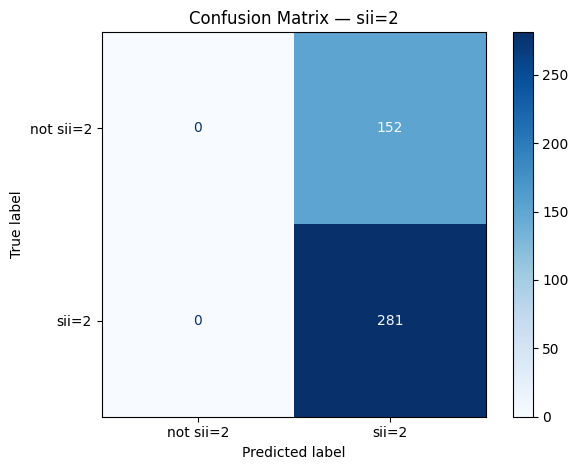

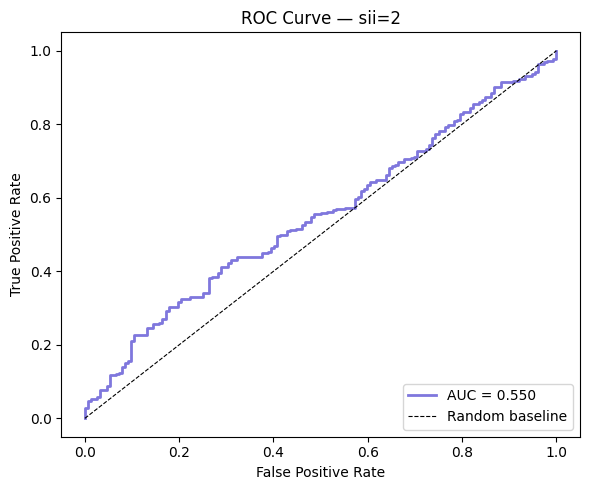

              precision    recall  f1-score   support

   not sii=2       0.00      0.00      0.00       152
       sii=2       0.65      1.00      0.79       281

    accuracy                           0.65       433
   macro avg       0.32      0.50      0.39       433
weighted avg       0.42      0.65      0.51       433


  Confusion Matrix breakdown:
    TN (correct negatives) : 0
    FP (false positives)   : 152
    FN (false negatives)   : 0
    TP (correct positives) : 281
    AUC                    : 0.5504


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

In [166]:
models[2] = train_one_step_svm(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=2')

In [167]:
# ── Assign predictions for step 3 ────────────────────────────────────────────
y_pred_te   = models[2].predict(X_te)

step_results[2] = {
    'step_name':    'sii=2 vs [3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 2

print(f"\n  Assigned as sii=2 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=2 : 433 samples


### class 3 

In [168]:
# ── Filter for next step ──────────────────────────────────────────────────────
mask_tr      = y_tr != 2
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")

  Remaining train : 59
  Remaining test  : 152


In [169]:
y_pred_final[original_idx] = 3
step_results[3] = {
    'step_name':    'sii=3 (remaining)',
    'y_true_bin':   (y_te == 3).astype(int),
    'y_pred_bin':   np.ones(len(y_te), dtype=int),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

print(f"\n  Assigned as sii=3 : {len(original_idx)} samples (all remaining)")


  Assigned as sii=3 : 152 samples (all remaining)


# RESULTS

In [170]:
# ══════════════════════════════════════════════════════════════════════════════
# REPORTE COMBINADO
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*75)
print("  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS")
print("="*75)

rows = []
for step, res in step_results.items():
    yt = res['y_true_bin']
    yp = res['y_pred_bin']

    # métricas binarias reales de cada paso
    prec   = precision_score(yt, yp, zero_division=0)
    rec    = recall_score(yt, yp, zero_division=0)
    f1     = f1_score(yt, yp, zero_division=0)
    n      = len(yt)
    n_pos  = yt.sum()
    tp     = ((yp == 1) & (yt == 1)).sum()
    fp     = ((yp == 1) & (yt == 0)).sum()
    fn     = ((yp == 0) & (yt == 1)).sum()

    rows.append({
        'Step':         res['step_name'],
        'N samples':    n,
        'N positive':   n_pos,
        'TP':           tp,
        'FP':           fp,
        'FN':           fn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
    })

report_df = pd.DataFrame(rows)
print(report_df.to_string(index=False))


  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS
             Step  N samples  N positive   TP  FP  FN  Precision  Recall     F1
 sii=0 vs [1,2,3]       2515        1738 1654 679  84     0.7090  0.9517 0.8126
   sii=1 vs [2,3]        861         470  428 274  42     0.6097  0.9106 0.7304
     sii=2 vs [3]        433         281  281 152   0     0.6490  1.0000 0.7871
sii=3 (remaining)        152          26   26 126   0     0.1711  1.0000 0.2921


In [171]:
# ── Multiclass final ──────────────────────────────────────────────────────────
print("\n" + "="*75)
print("  FINAL MULTICLASS REPORT (y_test vs y_pred_final)")
print("="*75)
print(classification_report(
    y_test, y_pred_final,
    target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']
))


  FINAL MULTICLASS REPORT (y_test vs y_pred_final)
              precision    recall  f1-score   support

       sii=0       1.00      0.95      0.98      1738
       sii=1       1.00      0.91      0.95       470
       sii=2       1.00      1.00      1.00       281
       sii=3       0.17      1.00      0.29        26

    accuracy                           0.95      2515
   macro avg       0.79      0.97      0.81      2515
weighted avg       0.99      0.95      0.97      2515



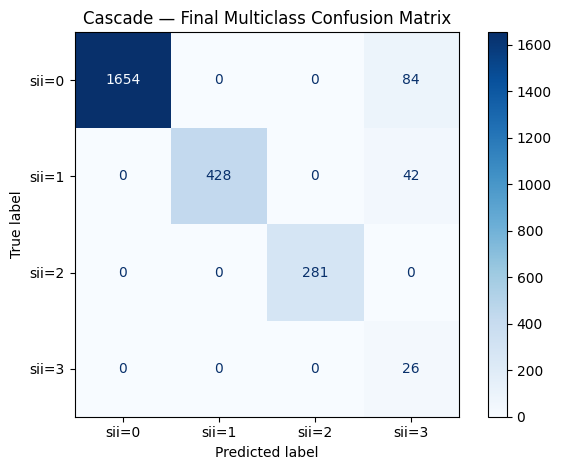

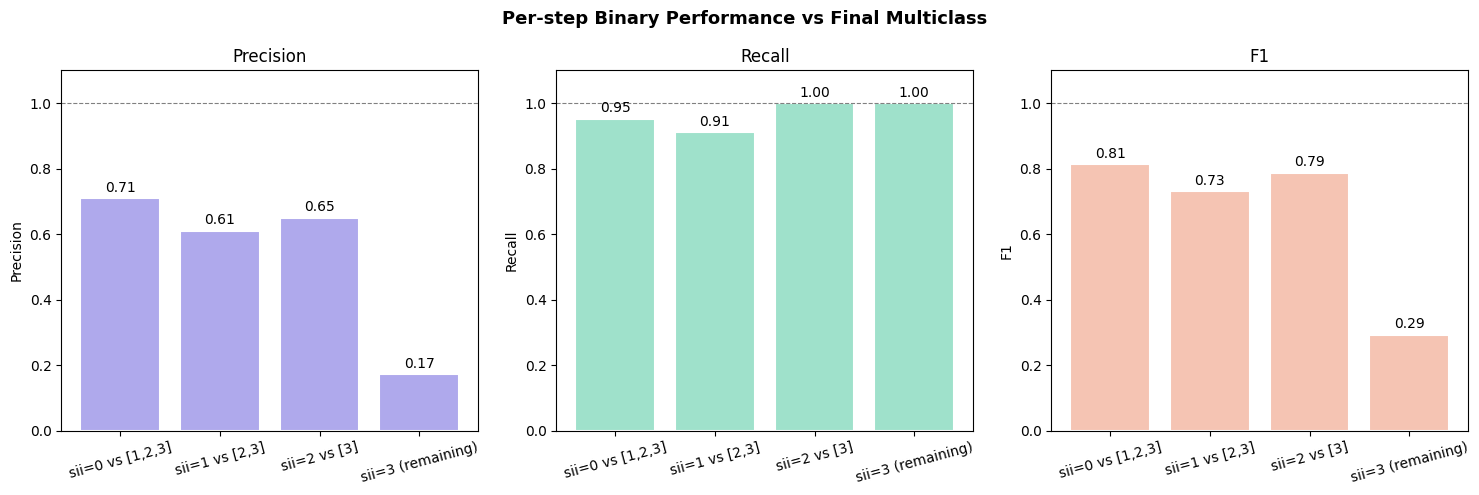

In [172]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sii=0', 'sii=1', 'sii=2', 'sii=3']
)
disp.plot(cmap='Blues')
plt.title('Cascade — Final Multiclass Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'F1']
colors    = ['#AFA9EC', '#9FE1CB', '#F5C4B3']

for ax, metric, color in zip(axes, metrics, colors):
    steps  = [r['Step'] for r in rows]
    values = [r[metric] for r in rows]
    bars   = ax.bar(steps, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Per-step Binary Performance vs Final Multiclass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [173]:
# ── Per class summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  PREDICTIONS SUMMARY")
print(f"{'='*60}")
for cls in [0, 1, 2, 3]:
    true_count = (y_test == cls).sum()
    pred_count = (y_pred_final == cls).sum()
    print(f"  sii={cls} → true: {true_count:<6} predicted: {pred_count}")


  PREDICTIONS SUMMARY
  sii=0 → true: 1738   predicted: 1654
  sii=1 → true: 470    predicted: 428
  sii=2 → true: 281    predicted: 281
  sii=3 → true: 26     predicted: 152


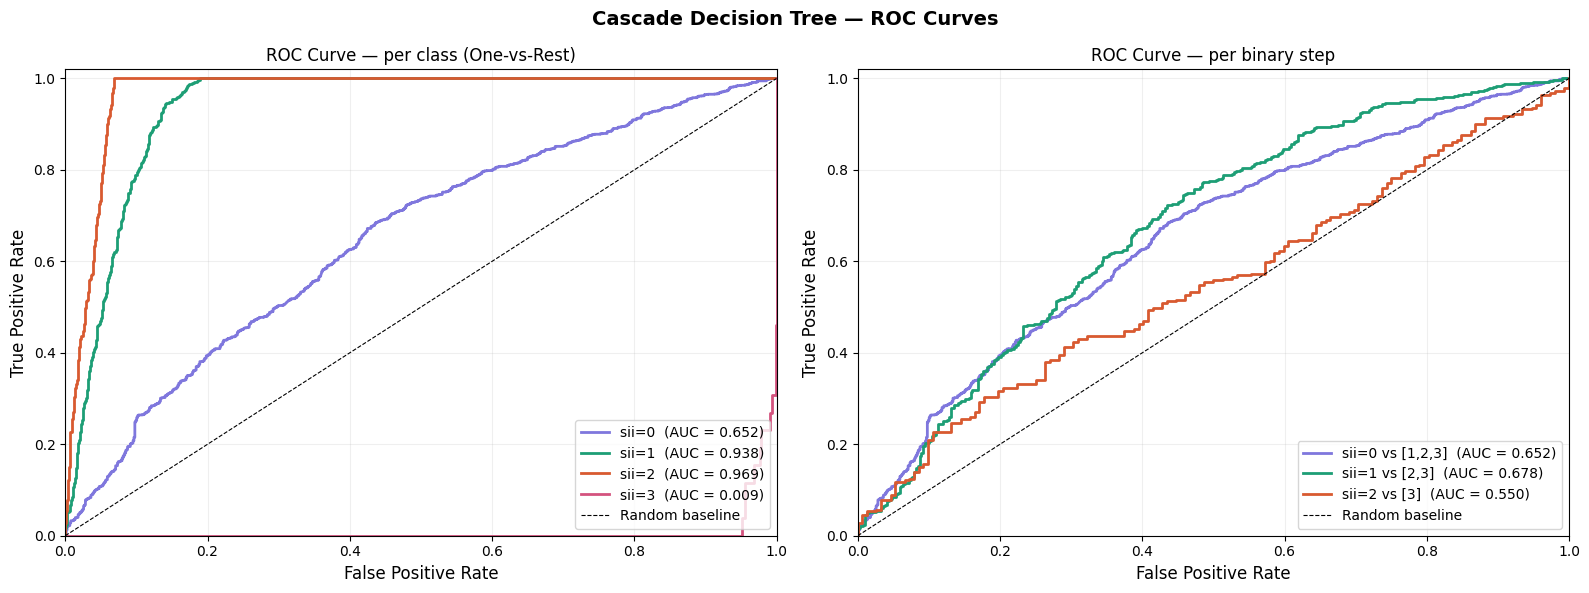


  AUC SUMMARY
  sii=0    → AUC = 0.6522
  sii=1    → AUC = 0.9385
  sii=2    → AUC = 0.9694
  sii=3    → AUC = 0.0089

  Macro AUC    : 0.6422
  Weighted AUC : 0.7345


In [174]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Collect probabilities from each step ───────────────────────────────────
# Each model gives P(class=X) for the samples it saw
# We need to reconstruct full probability matrix (n_test, 4)

n_test     = len(X_test)
proba_full = np.zeros((n_test, 4))   # one column per class

for step, res in step_results.items():
    idx    = res['original_idx']          # which original test samples this step saw
    model  = models.get(step)

    if model is not None:
        proba_step         = model.predict_proba(X_test[idx])   # shape (n_step, 2)
        proba_full[idx, step] = proba_step[:, 1]                # P(positive) for this class
    else:
        # last class — use survival probability (1 - sum of previous)
        proba_full[idx, step] = 1 - proba_full[idx, :step].sum(axis=1)

# ── 2. Binarize y_test for multiclass ROC ────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # shape (n_test, 4)

# ── 3. Compute ROC per class ──────────────────────────────────────────────────
colors     = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E']
step_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

for i in range(4):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_dict[i]                  = auc(fpr_dict[i], tpr_dict[i])

# ── 4. Plot — two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1 — individual ROC per class ───────────────────────────────────────
ax = axes[0]
for i in range(4):
    ax.plot(fpr_dict[i], tpr_dict[i],
            color=colors[i],
            linewidth=2,
            label=f"{step_names[i]}  (AUC = {auc_dict[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per class (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

# ── Panel 2 — step by step binary ROC ────────────────────────────────────────
ax = axes[1]
for step, res in step_results.items():
    model = models.get(step)
    if model is None:
        continue                              # skip last class (no model)

    idx        = res['original_idx']
    y_true_bin = res['y_true_bin']
    y_proba    = model.predict_proba(X_test[idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=colors[step],
            linewidth=2,
            label=f"{step_results[step]['step_name']}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per binary step', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

plt.suptitle('Cascade Decision Tree — ROC Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Print AUC summary ──────────────────────────────────────────────────────
print("\n" + "="*45)
print("  AUC SUMMARY")
print("="*45)
for i in range(4):
    print(f"  {step_names[i]:<8} → AUC = {auc_dict[i]:.4f}")

from sklearn.metrics import roc_auc_score
macro    = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='macro')
weighted = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='weighted')
print(f"\n  Macro AUC    : {macro:.4f}")
print(f"  Weighted AUC : {weighted:.4f}")
print("="*45)